# Game testing for Poker games profitable moves predictor


#### - The data was created in the other Notebook "01_Poker_data_preprocessing.ipynb".
#### - The exploratory data analysis was done in the other Notebook "02_Poker_exploratory_data_analysis.ipynb".
#### - The baseline model was created in the other Notebook "03_Poker_baseline_modeling.ipynb".
#### - The improved model was created in the other Notebook "04_Poker_model_improvement.ipynb".

As mentioned in the recommendations of the 4th notebook, the purpose of this notebook is to make all our models play against each other’s using a poker game engine. Then create some tournaments to figure out which models beat the others in real poker games. We could explore if the winners will be the same ones that we found have the best performance metrics in this notebook : I will do this in the next notebook: 05_game_testing.ipynb

To play the poker games we will be using the python library from pypokerengine

In [1]:
import pandas as pd
import numpy as np
from pypokerengine.players import BasePokerPlayer
import random as rand
from pypokerengine.utils.card_utils import gen_cards, estimate_hole_card_win_rate
from pypokerengine.api.game import setup_config, start_poker
import seaborn as sns
import matplotlib.pyplot as plt
from phevaluator.evaluator import evaluate_cards
from collections import Counter
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# general variables used in functions of this notebook

NB_SIMULATION = 1000
# for all the games the initial stack amount is 10000
INITIAL_STACK_AMOUNT = 10000
# for all the games the small blind amount is 50
SMALL_BLIND_AMOUNT = 50

# the function play_poker_games will play 100 tournaments
NB_GAME = 100
# Each tournament can have up to 10000 poker rounds played. 
# It means that one tournament ends at the end of 10000 games rounds and then we check which player has the most money. 
# Or it ends when one player has won all the money and the other players have 0
MAX_ROUND = 10000

# Functions

## Function chen_score
This function gets only the 2 starting cards as an input and return a calculated chen score. It uses the Chen formula

In [3]:
# Chen Formula for Texas Hold'em starting hand evaluation
# This program calculates the Chen score for any two-card starting hand.
RANK_VALUES = {
    'A': 10,  # Ace
    'K': 8,
    'Q': 7,
    'J': 6,
    'T': 5,   # Ten
    '9': 4.5,
    '8': 4,
    '7': 3.5,
    '6': 3,
    '5': 2.5,
    '4': 2,
    '3': 1.5,
    '2': 1
}

def chen_score(card1: str, card2: str) -> float:
    """
    This function gets only the 2 starting cards as an input
    and return a calculated chen score. It uses the Chen formula : https://en.wikipedia.org/wiki/Texas_hold_%27em_starting_hands
    
    Arguments
    ---------
    c1: string
           Card 1
    c2: string
           Card 2

    Returns
    --------
    score: float
         Number which represent the strength of the cards analyzed in the input. The higher the number is the stronger the 2 cards are
    """
    try:
        # Extract rank and suit
        rank1, suit1 = card1[0].upper(), card1[1].lower()
        rank2, suit2 = card2[0].upper(), card2[1].lower()

        if rank1 not in RANK_VALUES or rank2 not in RANK_VALUES:
            raise ValueError("Invalid card rank.")
        if suit1 not in "shdc" or suit2 not in "shdc":
            raise ValueError("Invalid card suit.")

        # Step 1: Base score = highest card value
        high_rank, low_rank = (rank1, rank2) if RANK_VALUES[rank1] >= RANK_VALUES[rank2] else (rank2, rank1)
        score = RANK_VALUES[high_rank]

        # Step 2: Pair bonus
        if rank1 == rank2:
            score *= 2
            if score < 5:
                score = 5  # Minimum for low pairs

        # Step 3: Suited bonus
        if suit1 == suit2:
            score += 2

        # Step 4: Gap penalty
        gap = abs(list(RANK_VALUES.keys()).index(high_rank) - list(RANK_VALUES.keys()).index(low_rank)) - 1
        if gap == 1:
            score -= 1
        elif gap == 2:
            score -= 2
        elif gap == 3:
            score -= 4
        elif gap >= 4:
            score -= 5

        # Step 5: Small gap + connectedness bonus
        if gap <= 1 and RANK_VALUES[low_rank] >= 5:  # 5 or higher
            score += 1

        return round(max(score, 0), 1)  # No negative scores

    except Exception as e:
        print(f"Error: {e}")
        return 0.0

## Function cards_score
This function gets a minimum of 2 cards and a maximum of 7 cards as an input and return a calculated card score. The lower the card score is, the better.

In [4]:
def cards_score(c1: str, c2: str, c3: str, c4: str, c5: str, c6: str, c7: str):
    """
    This function gets a minimum of 2 cards and a maximum of 7 cards as an input
    and return a calculated card score. The lower the card score is, the better.
    
    Arguments
    ---------
    c1: string
           Card 1
    c2: string
           Card 2
    c3: string
           Card 3
    c4: string
           Card 4
    c5: string
           Card 5
    c6: string
           Card 6
    c7: string
           Card 7

    Returns
    --------
    cards_score_result: float
         Number which represent the strength of the cards analyzed in the input. The lower the number is the stronger the hands of cards are.
    """
    cards_score_result = 0

    if (len(c1) > 0) & (len(c2) > 0) & (len(c3) == 0) & (len(c4) == 0) & (len(c5) == 0) & (len(c6) == 0) & (len(c7) == 0):
        # find a color not in the list of the first 2 cards
        list_colors = ['d', 'h', 's', 'c']
        c1_color = c1[1:2]
        c2_color = c2[1:2]
        list_colors.remove(c1_color)
        if c1_color != c2_color:
            list_colors.remove(c2_color)
        color_pick = list_colors[0]
        # find 3 other small cards to add to the initial 2 cards
        list_cards = ['2', '3', '4', '5', '6', '7']
        temp_cards_score_result = 0
        max_cards_score_result = 0
        for card3 in list_cards:
            for card4 in list_cards:
                for card5 in list_cards:
                    try:
                        temp_cards_score_result = evaluate_cards(c1, c2, card3 + color_pick, card4 + color_pick, card5 + color_pick)
                        if temp_cards_score_result >= max_cards_score_result:
                            max_cards_score_result = temp_cards_score_result
                    except Exception:
                        pass
        cards_score_result = max_cards_score_result
    elif (len(c1) > 0) & (len(c2) > 0) & (len(c3) > 0) & (len(c4) > 0) & (len(c5) > 0) & (len(c6) == 0) & (len(c7) == 0):
        cards_score_result = evaluate_cards(c1, c2, c3, c4, c5)
    elif (len(c1) > 0) & (len(c2) > 0) & (len(c3) > 0) & (len(c4) > 0) & (len(c5) > 0) & (len(c6) > 0) & (len(c7) == 0):
        cards_score_result = evaluate_cards(c1, c2, c3, c4, c5, c6)
    elif (len(c1) > 0) & (len(c2) > 0) & (len(c3) > 0) & (len(c4) > 0) & (len(c5) > 0) & (len(c6) > 0) & (len(c7) > 0):
        cards_score_result = evaluate_cards(c1, c2, c3, c4, c5, c6, c7)
    
    return cards_score_result

## Function calculate_nb_straight_player_cards
This function calculates the field nb_straight_player_cards

In [5]:
def calculate_nb_straight_player_cards(stage, c1: str, c2: str, c3: str, c4: str, c5: str, c6: str, c7: str):
    """
    This function calculates the field nb_straight_player_cards
    
    Arguments
    ---------
    stage: string
            The stage of the game
    c1: string
           Card 1
    c2: string
           Card 2
    c3: string
           Card 3
    c4: string
           Card 4
    c5: string
           Card 5
    c6: string
           Card 6
    c7: string
           Card 7

    Returns
    --------
    nb_straight_player_cards: float
         Number which represent the number of straight player cards
    """
    # we need to know just the cards without their colors
    c1s = c1[:1]
    c2s = c2[:1]
    c3s = c3[:1]
    c4s = c4[:1]
    c5s = c5[:1]
    c6s = c6[:1]
    c7s = c7[:1]
    # Bucket 1-5
    bucket_list = ['A', '2', '3', '4', '5']
    bucket_A_5_count = 0
    if c1s in bucket_list:
        bucket_A_5_count = bucket_A_5_count + 1
    if (c2s in bucket_list) & (c1s != c2s):
        bucket_A_5_count = bucket_A_5_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list) & (c3s != c1s) & (c3s != c2s):
        bucket_A_5_count = bucket_A_5_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c1s) & (c4s != c2s) & (c4s != c3s):
        bucket_A_5_count = bucket_A_5_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) & (c5s != c1s) & (c5s != c2s) & (c5s != c3s) & (c5s != c4s):
        bucket_A_5_count = bucket_A_5_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c1s) & (c6s != c2s) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_A_5_count = bucket_A_5_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c1s) & (c7s != c2s) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_A_5_count = bucket_A_5_count + 1

    # Bucket 2-6
    bucket_list = ['2', '3', '4', '5', '6']
    bucket_2_6_count = 0
    if c1s in bucket_list:
        bucket_2_6_count = bucket_2_6_count + 1
    if (c2s in bucket_list) & (c1s != c2s):
        bucket_2_6_count = bucket_2_6_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list) & (c3s != c1s) & (c3s != c2s):
        bucket_2_6_count = bucket_2_6_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c1s) & (c4s != c2s) & (c4s != c3s):
        bucket_2_6_count = bucket_2_6_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) & (c5s != c1s) & (c5s != c2s) & (c5s != c3s) & (c5s != c4s):
        bucket_2_6_count = bucket_2_6_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c1s) & (c6s != c2s) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_2_6_count = bucket_2_6_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c1s) & (c7s != c2s) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_2_6_count = bucket_2_6_count + 1

    # Bucket 3-7
    bucket_list = ['3', '4', '5', '6', '7']
    bucket_3_7_count = 0
    if c1s in bucket_list:
        bucket_3_7_count = bucket_3_7_count + 1
    if (c2s in bucket_list) & (c1s != c2s):
        bucket_3_7_count = bucket_3_7_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list) & (c3s != c1s) & (c3s != c2s):
        bucket_3_7_count = bucket_3_7_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c1s) & (c4s != c2s) & (c4s != c3s):
        bucket_3_7_count = bucket_3_7_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) & (c5s != c1s) & (c5s != c2s) & (c5s != c3s) & (c5s != c4s):
        bucket_3_7_count = bucket_3_7_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c1s) & (c6s != c2s) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_3_7_count = bucket_3_7_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c1s) & (c7s != c2s) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_3_7_count = bucket_3_7_count + 1

    # Bucket 4-8
    bucket_list = ['4', '5', '6', '7', '8']
    bucket_4_8_count = 0
    if c1s in bucket_list:
        bucket_4_8_count = bucket_4_8_count + 1
    if (c2s in bucket_list) & (c1s != c2s):
        bucket_4_8_count = bucket_4_8_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list) & (c3s != c1s) & (c3s != c2s):
        bucket_4_8_count = bucket_4_8_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c1s) & (c4s != c2s) & (c4s != c3s):
        bucket_4_8_count = bucket_4_8_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) & (c5s != c1s) & (c5s != c2s) & (c5s != c3s) & (c5s != c4s):
        bucket_4_8_count = bucket_4_8_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c1s) & (c6s != c2s) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_4_8_count = bucket_4_8_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c1s) & (c7s != c2s) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_4_8_count = bucket_4_8_count + 1

    # Bucket 5-9
    bucket_list = ['5', '6', '7', '8', '9']
    bucket_5_9_count = 0
    if c1s in bucket_list:
        bucket_5_9_count = bucket_5_9_count + 1
    if (c2s in bucket_list) & (c1s != c2s):
        bucket_5_9_count = bucket_5_9_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list) & (c3s != c1s) & (c3s != c2s):
        bucket_5_9_count = bucket_5_9_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c1s) & (c4s != c2s) & (c4s != c3s):
        bucket_5_9_count = bucket_5_9_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) & (c5s != c1s) & (c5s != c2s) & (c5s != c3s) & (c5s != c4s):
        bucket_5_9_count = bucket_5_9_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c1s) & (c6s != c2s) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_5_9_count = bucket_5_9_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c1s) & (c7s != c2s) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_5_9_count = bucket_5_9_count + 1

    # Bucket 6-T
    bucket_list = ['6', '7', '8', '9', 'T']
    bucket_6_T_count = 0
    if c1s in bucket_list:
        bucket_6_T_count = bucket_6_T_count + 1
    if (c2s in bucket_list) & (c1s != c2s):
        bucket_6_T_count = bucket_6_T_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list) & (c3s != c1s) & (c3s != c2s):
        bucket_6_T_count = bucket_6_T_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c1s) & (c4s != c2s) & (c4s != c3s):
        bucket_6_T_count = bucket_6_T_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) & (c5s != c1s) & (c5s != c2s) & (c5s != c3s) & (c5s != c4s):
        bucket_6_T_count = bucket_6_T_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c1s) & (c6s != c2s) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_6_T_count = bucket_6_T_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c1s) & (c7s != c2s) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_6_T_count = bucket_6_T_count + 1

    # Bucket 7-J
    bucket_list = ['7', '8', '9', 'T', 'J']
    bucket_7_J_count = 0
    if c1s in bucket_list:
        bucket_7_J_count = bucket_7_J_count + 1
    if (c2s in bucket_list) & (c1s != c2s):
        bucket_7_J_count = bucket_7_J_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list) & (c3s != c1s) & (c3s != c2s):
        bucket_7_J_count = bucket_7_J_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c1s) & (c4s != c2s) & (c4s != c3s):
        bucket_7_J_count = bucket_7_J_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) & (c5s != c1s) & (c5s != c2s) & (c5s != c3s) & (c5s != c4s):
        bucket_7_J_count = bucket_7_J_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c1s) & (c6s != c2s) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_7_J_count = bucket_7_J_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c1s) & (c7s != c2s) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_7_J_count = bucket_7_J_count + 1

    # Bucket 8-Q
    bucket_list = ['8', '9', 'T', 'J', 'Q']
    bucket_8_Q_count = 0
    if c1s in bucket_list:
        bucket_8_Q_count = bucket_8_Q_count + 1
    if (c2s in bucket_list) & (c1s != c2s):
        bucket_8_Q_count = bucket_8_Q_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list) & (c3s != c1s) & (c3s != c2s):
        bucket_8_Q_count = bucket_8_Q_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c1s) & (c4s != c2s) & (c4s != c3s):
        bucket_8_Q_count = bucket_8_Q_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) & (c5s != c1s) & (c5s != c2s) & (c5s != c3s) & (c5s != c4s):
        bucket_8_Q_count = bucket_8_Q_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c1s) & (c6s != c2s) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_8_Q_count = bucket_8_Q_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c1s) & (c7s != c2s) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_8_Q_count = bucket_8_Q_count + 1

    # Bucket 9-K
    bucket_list = ['9', 'T', 'J', 'Q', 'K']
    bucket_9_K_count = 0
    if c1s in bucket_list:
        bucket_9_K_count = bucket_9_K_count + 1
    if (c2s in bucket_list) & (c1s != c2s):
        bucket_9_K_count = bucket_9_K_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list) & (c3s != c1s) & (c3s != c2s):
        bucket_9_K_count = bucket_9_K_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c1s) & (c4s != c2s) & (c4s != c3s):
        bucket_9_K_count = bucket_9_K_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) & (c5s != c1s) & (c5s != c2s) & (c5s != c3s) & (c5s != c4s):
        bucket_9_K_count = bucket_9_K_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c1s) & (c6s != c2s) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_9_K_count = bucket_9_K_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c1s) & (c7s != c2s) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_9_K_count = bucket_9_K_count + 1

    # Bucket T-A
    bucket_list = ['T', 'J', 'Q', 'K', 'A']
    bucket_T_A_count = 0
    if c1s in bucket_list:
        bucket_T_A_count = bucket_T_A_count + 1
    if (c2s in bucket_list) & (c1s != c2s):
        bucket_T_A_count = bucket_T_A_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list) & (c3s != c1s) & (c3s != c2s):
        bucket_T_A_count = bucket_T_A_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c1s) & (c4s != c2s) & (c4s != c3s):
        bucket_T_A_count = bucket_T_A_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) & (c5s != c1s) & (c5s != c2s) & (c5s != c3s) & (c5s != c4s):
        bucket_T_A_count = bucket_T_A_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c1s) & (c6s != c2s) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_T_A_count = bucket_T_A_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c1s) & (c7s != c2s) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_T_A_count = bucket_T_A_count + 1

    nb_straight_player_cards = max([bucket_A_5_count, bucket_2_6_count, bucket_3_7_count, bucket_4_8_count, bucket_5_9_count, bucket_6_T_count, bucket_7_J_count, bucket_8_Q_count, bucket_9_K_count, bucket_T_A_count])

    
    return nb_straight_player_cards

## Function calculate_nb_straight_community_cards
This function calculates the field nb_straight_community_cards

In [6]:
def calculate_nb_straight_community_cards(stage, c3: str, c4: str, c5: str, c6: str, c7: str):
    """
    This function calculates the field nb_straight_community_cards
    
    Arguments
    ---------
    stage: string
            The stage of the game
    c3: string
           Card 3
    c4: string
           Card 4
    c5: string
           Card 5
    c6: string
           Card 6
    c7: string
           Card 7

    Returns
    --------
    nb_straight_community_cards: float
         Number which represent the number of straight community cards
    """
    # we need to know just the cards without their colors
    c3s = c3[:1]
    c4s = c4[:1]
    c5s = c5[:1]
    c6s = c6[:1]
    c7s = c7[:1]
    # Bucket 1-5
    bucket_list = ['A', '2', '3', '4', '5']
    bucket_A_5_count = 0
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list):
        bucket_A_5_count = bucket_A_5_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c3s):
        bucket_A_5_count = bucket_A_5_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) &  (c5s != c3s) & (c5s != c4s):
        bucket_A_5_count = bucket_A_5_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_A_5_count = bucket_A_5_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_A_5_count = bucket_A_5_count + 1

    # Bucket 2-6
    bucket_list = ['2', '3', '4', '5', '6']
    bucket_2_6_count = 0
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list):
        bucket_2_6_count = bucket_2_6_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c3s):
        bucket_2_6_count = bucket_2_6_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) &  (c5s != c3s) & (c5s != c4s):
        bucket_2_6_count = bucket_2_6_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_2_6_count = bucket_2_6_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_2_6_count = bucket_2_6_count + 1

    # Bucket 3-7
    bucket_list = ['3', '4', '5', '6', '7']
    bucket_3_7_count = 0
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list):
        bucket_3_7_count = bucket_3_7_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c3s):
        bucket_3_7_count = bucket_3_7_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) &  (c5s != c3s) & (c5s != c4s):
        bucket_3_7_count = bucket_3_7_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_3_7_count = bucket_3_7_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_3_7_count = bucket_3_7_count + 1

    # Bucket 4-8
    bucket_list = ['4', '5', '6', '7', '8']
    bucket_4_8_count = 0
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list):
        bucket_4_8_count = bucket_4_8_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c3s):
        bucket_4_8_count = bucket_4_8_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) &  (c5s != c3s) & (c5s != c4s):
        bucket_4_8_count = bucket_4_8_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_4_8_count = bucket_4_8_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_4_8_count = bucket_4_8_count + 1

    # Bucket 5-9
    bucket_list = ['5', '6', '7', '8', '9']
    bucket_5_9_count = 0
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list):
        bucket_5_9_count = bucket_5_9_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c3s):
        bucket_5_9_count = bucket_5_9_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) &  (c5s != c3s) & (c5s != c4s):
        bucket_5_9_count = bucket_5_9_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_5_9_count = bucket_5_9_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_5_9_count = bucket_5_9_count + 1

    # Bucket 6-T
    bucket_list = ['6', '7', '8', '9', 'T']
    bucket_6_T_count = 0
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list):
        bucket_6_T_count = bucket_6_T_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c3s):
        bucket_6_T_count = bucket_6_T_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) &  (c5s != c3s) & (c5s != c4s):
        bucket_6_T_count = bucket_6_T_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_6_T_count = bucket_6_T_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_6_T_count = bucket_6_T_count + 1

    # Bucket 7-J
    bucket_list = ['7', '8', '9', 'T', 'J']
    bucket_7_J_count = 0
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list):
        bucket_7_J_count = bucket_7_J_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c3s):
        bucket_7_J_count = bucket_7_J_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) &  (c5s != c3s) & (c5s != c4s):
        bucket_7_J_count = bucket_7_J_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_7_J_count = bucket_7_J_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_7_J_count = bucket_7_J_count + 1

    # Bucket 8-Q
    bucket_list = ['8', '9', 'T', 'J', 'Q']
    bucket_8_Q_count = 0
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list):
        bucket_8_Q_count = bucket_8_Q_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c3s):
        bucket_8_Q_count = bucket_8_Q_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) &  (c5s != c3s) & (c5s != c4s):
        bucket_8_Q_count = bucket_8_Q_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_8_Q_count = bucket_8_Q_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_8_Q_count = bucket_8_Q_count + 1

    # Bucket 9-K
    bucket_list = ['9', 'T', 'J', 'Q', 'K']
    bucket_9_K_count = 0
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list):
        bucket_9_K_count = bucket_9_K_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c3s):
        bucket_9_K_count = bucket_9_K_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) &  (c5s != c3s) & (c5s != c4s):
        bucket_9_K_count = bucket_9_K_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_9_K_count = bucket_9_K_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_9_K_count = bucket_9_K_count + 1

    # Bucket T-A
    bucket_list = ['T', 'J', 'Q', 'K', 'A']
    bucket_T_A_count = 0
    if (stage in ['flop', 'turn', 'river']) & (c3s in bucket_list):
        bucket_T_A_count = bucket_T_A_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4s in bucket_list) & (c4s != c3s):
        bucket_T_A_count = bucket_T_A_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5s in bucket_list) &  (c5s != c3s) & (c5s != c4s):
        bucket_T_A_count = bucket_T_A_count + 1
    if (stage in ['turn', 'river']) & (c6s in bucket_list) & (c6s != c3s) & (c6s != c4s) & (c6s != c5s):
        bucket_T_A_count = bucket_T_A_count + 1
    if (stage in ['river']) & (c7s in bucket_list) & (c7s != c3s) & (c7s != c4s) & (c7s != c5s) & (c7s != c6s):
        bucket_T_A_count = bucket_T_A_count + 1

    nb_straight_community_cards = max([bucket_A_5_count, bucket_2_6_count, bucket_3_7_count, bucket_4_8_count, bucket_5_9_count, bucket_6_T_count, bucket_7_J_count, bucket_8_Q_count, bucket_9_K_count, bucket_T_A_count])

    
    return nb_straight_community_cards

## Function calculate_nb_flush_player_cards
This function calculates the field nb_flush_player_cards

In [7]:
def calculate_nb_flush_player_cards(stage, c1: str, c2: str, c3: str, c4: str, c5: str, c6: str, c7: str):
    """
    This function calculates the field nb_flush_player_cards
    
    Arguments
    ---------
    stage: string
            The stage of the game
    c1: string
           Card 1
    c2: string
           Card 2
    c3: string
           Card 3
    c4: string
           Card 4
    c5: string
           Card 5
    c6: string
           Card 6
    c7: string
           Card 7

    Returns
    --------
    nb_flush_player_cards: float
         Number which represent the number of flush player cards
    """
    # we need to know just the cards with their colors only
    c1c = c1[1:]
    c2c = c2[1:]
    c3c = c3[1:]
    c4c = c4[1:]
    c5c = c5[1:]
    c6c = c6[1:]
    c7c = c7[1:]

    clubs_count = 0
    if c1c == 'c':
        clubs_count = clubs_count + 1
    if c2c == 'c':
        clubs_count = clubs_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c3c == 'c'):
        clubs_count = clubs_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4c == 'c'):
        clubs_count = clubs_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5c == 'c'):
        clubs_count = clubs_count + 1
    if (stage in ['turn', 'river']) & (c6c == 'c'):
        clubs_count = clubs_count + 1 
    if (stage in ['river']) & (c7c == 'c'):
        clubs_count = clubs_count + 1

    spades_count = 0
    if c1c == 's':
        spades_count = spades_count + 1
    if c2c == 's':
        spades_count = spades_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c3c == 's'):
        spades_count = spades_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4c == 's'):
        spades_count = spades_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5c == 's'):
        spades_count = spades_count + 1
    if (stage in ['turn', 'river']) & (c6c == 's'):
        spades_count = spades_count + 1 
    if (stage in ['river']) & (c7c == 's'):
        spades_count = spades_count + 1 

    hearts_count = 0
    if c1c == 'h':
        hearts_count = hearts_count + 1
    if c2c == 'h':
        hearts_count = hearts_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c3c == 'h'):
        hearts_count = hearts_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4c == 'h'):
        hearts_count = hearts_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5c == 'h'):
        hearts_count = hearts_count + 1
    if (stage in ['turn', 'river']) & (c6c == 'h'):
        hearts_count = hearts_count + 1 
    if (stage in ['river']) & (c7c == 'h'):
        hearts_count = hearts_count + 1

    diamonds_count = 0
    if c1c == 'd':
        diamonds_count = diamonds_count + 1
    if c2c == 'd':
        diamonds_count = diamonds_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c3c == 'd'):
        diamonds_count = diamonds_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4c == 'd'):
        diamonds_count = diamonds_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5c == 'd'):
        diamonds_count = diamonds_count + 1
    if (stage in ['turn', 'river']) & (c6c == 'd'):
        diamonds_count = diamonds_count + 1 
    if (stage in ['river']) & (c7c == 'd'):
        diamonds_count = diamonds_count + 1

    nb_flush_player_cards = max([clubs_count, spades_count, hearts_count, diamonds_count])
    
    return nb_flush_player_cards

## Function calculate_nb_flush_community_cards
This function calculates the field nb_flush_community_cards

In [8]:
def calculate_nb_flush_community_cards(stage, c3: str, c4: str, c5: str, c6: str, c7: str):
    """
    This function calculates the field nb_flush_community_cards
    
    Arguments
    ---------
    stage: string
            The stage of the game
    c3: string
           Card 3
    c4: string
           Card 4
    c5: string
           Card 5
    c6: string
           Card 6
    c7: string
           Card 7

    Returns
    --------
    nb_flush_player_cards: float
         Number which represent the number of flush community cards
    """
    # we need to know just the cards with their colors only
    c3c = c3[1:]
    c4c = c4[1:]
    c5c = c5[1:]
    c6c = c6[1:]
    c7c = c7[1:]

    clubs_count = 0
    if (stage in ['flop', 'turn', 'river']) & (c3c == 'c'):
        clubs_count = clubs_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4c == 'c'):
        clubs_count = clubs_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5c == 'c'):
        clubs_count = clubs_count + 1
    if (stage in ['turn', 'river']) & (c6c == 'c'):
        clubs_count = clubs_count + 1 
    if (stage in ['river']) & (c7c == 'c'):
        clubs_count = clubs_count + 1

    spades_count = 0
    if (stage in ['flop', 'turn', 'river']) & (c3c == 's'):
        spades_count = spades_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4c == 's'):
        spades_count = spades_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5c == 's'):
        spades_count = spades_count + 1
    if (stage in ['turn', 'river']) & (c6c == 's'):
        spades_count = spades_count + 1 
    if (stage in ['river']) & (c7c == 's'):
        spades_count = spades_count + 1 

    hearts_count = 0
    if (stage in ['flop', 'turn', 'river']) & (c3c == 'h'):
        hearts_count = hearts_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4c == 'h'):
        hearts_count = hearts_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5c == 'h'):
        hearts_count = hearts_count + 1
    if (stage in ['turn', 'river']) & (c6c == 'h'):
        hearts_count = hearts_count + 1 
    if (stage in ['river']) & (c7c == 'h'):
        hearts_count = hearts_count + 1

    diamonds_count = 0
    if (stage in ['flop', 'turn', 'river']) & (c3c == 'd'):
        diamonds_count = diamonds_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c4c == 'd'):
        diamonds_count = diamonds_count + 1
    if (stage in ['flop', 'turn', 'river']) & (c5c == 'd'):
        diamonds_count = diamonds_count + 1
    if (stage in ['turn', 'river']) & (c6c == 'd'):
        diamonds_count = diamonds_count + 1 
    if (stage in ['river']) & (c7c == 'd'):
        diamonds_count = diamonds_count + 1

    nb_flush_community_cards = max([clubs_count, spades_count, hearts_count, diamonds_count])
    
    return nb_flush_community_cards

## Function countCards
This function counts cards in order to calculate the number of pairs ,sets or quads in the community cards

In [9]:
def countCards(c1: str, c2: str, c3: str, c4: str, c5: str, nb_cards_occurence):
    """
    This function counts cards in order to calculate the number of pairs ,sets or quads in the community cards
    
    Arguments
    ---------
    nb_cards_occurence: string
            Number of occurences for the cards (2 to calculate the number of pairs in the community cards, 3 for the sets and 4 for the quads)
    c1: string
           Card 1
    c2: string
           Card 2
    c3: string
           Card 3
    c4: string
           Card 4
    c5: string
           Card 5

    Returns
    --------
    number: float
         Number of pairs ,sets or quads in the community cards
    """
    # we need to know just the cards without their colors
    c1s = c1[:1]
    c2s = c2[:1]
    c3s = c3[:1]
    c4s = c4[:1]
    c5s = c5[:1]
    input_list = [c1s, c2s, c3s, c4s, c5s]
    # remove empty elements from the input list
    filtered_prelist = [x for x in input_list if not pd.isnull(x)]
    filtered_list = [x for x in filtered_prelist if x]
    # Count occurrences
    counts = Counter(filtered_list)
    
    # Filter duplicates
    duplicates = {item: count for item, count in counts.items() if count >= nb_cards_occurence}

    dict_length = len(duplicates)
    
    return dict_length

## Function calculate_game_info
This function calculates the game info from the game engine and returns a dataframe of input data which can be passed as an input to our PKL files

In [10]:
def calculate_game_info(self, valid_actions, hole_card, round_state):
    """
    This function calculates the game info from the game engine and returns a dataframe of input data which can be passed as an input to our PKL files
    
    Arguments
    ---------
    self: self parameter from the game engine
    valid_actions: list of valid actions from the game engine
    hole_card: list of hole cards from the game engine
    round_state: list of round_state from the game engine

    Returns
    --------
    Dataframe of input data which can be passed as an input to our PKL files
    """
    
    player_uuid = self.uuid
    # calculate game_id
    game_id = round_state['round_count']
    # calculate player_id
    player_id = ''
    seats = round_state['seats']
    for seat in seats:
        if seat['uuid'] == player_uuid:
            player_id = seat['name'][:2]
            player_name = seat['name'][3:]
    
    stage = round_state['street']
    # calculate sub_stage
    action_histories_stage = round_state['action_histories'][stage]
    sub_stage = 1
    for action_history in action_histories_stage:
        if action_history['uuid'] == player_uuid:
            sub_stage = sub_stage + 1
    if sub_stage > 3:
        sub_stage = 3
    # calculate stage_int
    stage_int = 0
    if (stage == 'preflop') & (sub_stage == 1):
        stage_int = 1
    elif (stage == 'preflop') & (sub_stage == 2):
        stage_int = 2
    elif (stage == 'preflop') & (sub_stage == 3):
        stage_int = 3
    elif (stage == 'flop') & (sub_stage == 1):
        stage_int = 4
    elif (stage == 'flop') & (sub_stage == 2):
        stage_int = 5
    elif (stage == 'flop') & (sub_stage == 3):
        stage_int = 6
    elif (stage == 'turn') & (sub_stage == 1):
        stage_int = 7
    elif (stage == 'turn') & (sub_stage == 2):
        stage_int = 8
    elif (stage == 'turn') & (sub_stage == 3):
        stage_int = 9
    elif (stage == 'river') & (sub_stage == 1):
        stage_int = 10
    elif (stage == 'river') & (sub_stage == 2):
        stage_int = 11
    elif (stage == 'river') & (sub_stage == 3):
        stage_int = 12
    # calculate nb_players_initial
    nb_players_initial = len(round_state['seats'])
               
    # calculate position_int      
    position_int = 0
    small_blind_pos = int(round_state['small_blind_pos'])
    dealer_btn = int(round_state['dealer_btn'])

    if (int(player_id[1:2]) - small_blind_pos) % nb_players_initial == 0:
        position_int = nb_players_initial
    else:
        position_int = (int(player_id[1:2]) - small_blind_pos) % nb_players_initial

    # calculate cards
    cards = hole_card[0][1:2] + hole_card[0][:1].lower() + hole_card[1][1:2] + hole_card[1][:1].lower()

    # calculate flop
    community_card = round_state['community_card']
    if len(community_card) == 3:
        flop = community_card[0][1:2] + community_card[0][:1].lower() + community_card[1][1:2] + community_card[1][:1].lower() + community_card[2][1:2] + community_card[2][:1].lower()
        turn = ""
        river = ""
    elif len(community_card) == 4:
        flop = community_card[0][1:2] + community_card[0][:1].lower() + community_card[1][1:2] + community_card[1][:1].lower() + community_card[2][1:2] + community_card[2][:1].lower()
        turn = community_card[3][1:2] + community_card[3][:1].lower()
        river = ""
    elif len(community_card) == 5:
        flop = community_card[0][1:2] + community_card[0][:1].lower() + community_card[1][1:2] + community_card[1][:1].lower() + community_card[2][1:2] + community_card[2][:1].lower()
        turn = community_card[3][1:2] + community_card[3][:1].lower()
        river = community_card[4][1:2] + community_card[4][:1].lower()
    else:
        flop = ""
        turn = ""
        river = ""
    # calculate amount_required
    amount_required = 0
    for action in valid_actions:
        if action['action'] == 'call':
            amount_required = action['amount']

    # calculate amount_committed
    action_histories = round_state['action_histories']
    amount_committed = 0
    for action_stage, action_history in action_histories.items():
        for action in action_history:
            if action['uuid'] == player_uuid:
                if action['action'] in ['SMALLBLIND','BIGBLIND']:
                    amount_committed = amount_committed + action['amount']
                if action['action'] in ['CALL', 'RAISE']:
                    amount_committed = amount_committed + action['paid']

    # calculate nb_players_left
    nb_players_left = 0
    seats = round_state['seats']
    for seat in seats:
        if seat['state'] == 'participating':
            nb_players_left = nb_players_left + 1

    # calculate player_stack
    player_stack = 0
    seats = round_state['seats']
    for seat in seats:
        if seat['uuid'] == player_uuid:
            player_stack = seat['stack']

    # calculate nb_previous_raise
    action_histories = round_state['action_histories']
    nb_previous_raise = 0
    for action_stage, action_history in action_histories.items():
        for action in action_history:
            if action['uuid'] == player_uuid:
                if action['action'] == 'RAISE':
                    nb_previous_raise = nb_previous_raise + 1

    # calculate c1, c2, c3, c4, c5, c6, c7
    c1 = cards[0:2]
    c2 = cards[2:4]
    c3 = flop[0:2]
    c4 = flop[2:4]
    c5 = flop[4:6]
    c6 = turn
    c7 = river

    # calculate nb_straight_player_cards
    nb_straight_player_cards = calculate_nb_straight_player_cards(stage, c1, c2, c3, c4, c5, c6, c7)

    # calculate nb_straight_community_cards
    nb_straight_community_cards = calculate_nb_straight_community_cards(stage, c3, c4, c5, c6, c7)

    # calculate nb_flush_player_cards
    nb_flush_player_cards = calculate_nb_flush_player_cards(stage, c1, c2, c3, c4, c5, c6, c7)

    # calculate nb_flush_community_cards
    nb_flush_community_cards = calculate_nb_flush_community_cards(stage, c3, c4, c5, c6, c7)

    # calculate nb_pairs_community_cards
    nb_pairs_community_cards = countCards(c3, c4, c5, c6, c7, 2)

    # calculate nb_sets_community_cards
    nb_sets_community_cards = countCards(c3, c4, c5, c6, c7, 3)

    # calculate nb_quads_community_cards
    nb_quads_community_cards = countCards(c3, c4, c5, c6, c7, 4)
    
    # calculate chen_score
    chen_score_value = chen_score(c1, c2)

    # calculate cards_score
    cards_score_value = cards_score(c1, c2, c3, c4, c5, c6, c7)

    # calculate minimum_bet
    minimum_bet = round_state['small_blind_amount'] * 2

    df_input_data = pd.DataFrame(
        {'game_id': [game_id], 
        'player_id' : [player_id],
        'player_uuid' : [player_uuid],
        'player_name' : [player_name],   
        'stage' : [stage],          
        'sub_stage' : [sub_stage],          
        'stage_int' : [stage_int],  
        'position_int' : [position_int],  
        'cards' : [cards],  
        'flop' : [flop],  
        'turn' : [turn],  
        'river' : [river],        
        'amount_required' : [amount_required],   
        'amount_committed' : [amount_committed], 
        'nb_players_left' : [nb_players_left],
        'nb_previous_raise' : [nb_previous_raise],
        'nb_straight_player_cards' : [nb_straight_player_cards],
        'nb_straight_community_cards' : [nb_straight_community_cards], 
        'nb_flush_player_cards' : [nb_flush_player_cards], 
        'nb_flush_community_cards' : [nb_flush_community_cards], 
        'nb_pairs_community_cards' : [nb_pairs_community_cards], 
        'nb_sets_community_cards' : [nb_sets_community_cards], 
        'nb_quads_community_cards' : [nb_quads_community_cards], 
        'chen_score' : [chen_score_value], 
        'cards_score' : [cards_score_value], 
        'minimum_bet' : [minimum_bet],
        'player_stack' : [player_stack],         
        }).set_index(['game_id', 'player_id', 'stage_int'])

    return df_input_data

## Function format_predictions
This function format the predictions

In [11]:
def format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack):
    """
    This function counts cards in order to calculate the number of pairs ,sets or quads in the community cards
    
    Arguments
    ---------
    nb_cards_occurence: string
            Number of occurences for the cards (2 to calculate the number of pairs in the community cards, 3 for the sets and 4 for the quads)
    prediction_classification: number
           Prediction result from the classification PKL model to predict the action (could be 0 for Fold, 1 for Call or 2 for Raise)
    prediction_regression: number
           Prediction result from the regression PKL model to predict the amount to raise
    valid_actions: list of valid actions from the game engine
    player_stack: number
           Initial stack of the player

    Returns
    --------
    prediction_classification_formatted: string: the final classification result reformatted
    prediction_regression_formatted: number: the final regression result reformatted
    """
    # use weight for the raise amnount
    if prediction_classification == 1:
        final_action = 'call'
        final_amount = valid_actions[1]['amount']
    elif prediction_classification == 2:
        final_action = 'raise'
        min_raise = valid_actions[2]['amount']['min']
        if prediction_regression <= valid_actions[2]['amount']['min']:
            final_amount = valid_actions[2]['amount']['min']
        elif prediction_regression >= valid_actions[2]['amount']['max']:
            final_amount = valid_actions[2]['amount']['max']
        else:
            final_amount = round(prediction_regression, 0)
    else:
        final_action = 'fold'
        final_amount = 0
    return final_action, final_amount

## Function play_poker_games
This function plays poker games using the poker engine

In [12]:
def play_poker_games(df_player):
    """
    This function plays poker games using the poker engine
    
    Arguments
    ---------
    df_player: Dataframe
            Dataframe representing the player

    Returns
    --------
    df_tournament_result: Dataframe of the poker tournament result
    """
    # calculate the number of players
    nb_players = len(df_player)

    df_tournament_result = pd.DataFrame(columns=["player_name", "points"])
    for i in range(0, nb_players):
        df_tournament_result.loc[len(df_tournament_result)] = [df_player.iloc[i]['player_name'], 0]

    for n in range(1, NB_GAME + 1):
        config = setup_config(max_round=MAX_ROUND, initial_stack=INITIAL_STACK_AMOUNT, small_blind_amount=SMALL_BLIND_AMOUNT)
        for i in range(0, nb_players):
            config.register_player(name=df_player.iloc[i]['player_id'] + '_' + df_player.iloc[i]['player_name'], algorithm=df_player.iloc[i]['algorithm'])

        game_result = start_poker(config, verbose=0)

        df_game_result = pd.DataFrame(columns=["player_name", "stack"])
        for i in range(0, nb_players):
            df_game_result.loc[len(df_game_result)] = [df_player.iloc[i]['player_name'], game_result['players'][i]['stack']]
        
        df_game_result = df_game_result.sort_values(by = 'stack', ascending = False)
        # get the winner
        df_game_result.iloc[0]['player_name']
        #print('The winner of round ' + str(n) + ' is: ' + df_game_result.iloc[0]['player_name'])
        df_tournament_result.loc[df_tournament_result['player_name'] == df_game_result.iloc[0]['player_name'], 'points'] = df_tournament_result['points'] + 1
    
    df_tournament_result = df_tournament_result.sort_values(by = 'points', ascending = False)

    return df_tournament_result

## Function plot_poker_games_results
This function plot poker games results

In [13]:
def plot_poker_games_results(df_tournament_result, comment):
    """
    This function plots the poker games results
    
    Arguments
    ---------
    df_tournament_result: Dataframe
            Dataframe representing the poker tournament result
    comment: string
            Comment specific to the plot
    Returns
    --------
    creates a Seaborn plot
    """
    # plot poker games results
    sns.barplot(x='player_name', y='points', data=df_tournament_result).tick_params(axis='x', labelrotation=90)
    plt.title('Poker game results ' + comment)
    plt.savefig("images\\Game_testing\\Poker_game_results_" + comment + ".png", bbox_inches='tight')

# Classes
Each class will either :
- be using a specific poker classification and regression model from the folder "models", in order to play poker games
- or be using some very basic algorithms like for the FoldPlayer which always just fold, CallPlayer which always just call, RaisePlayer which always raise, or RandomPlayer which plays randomly, or HonestPlayer which has another basic algorithm

In [14]:
class FoldPlayer(BasePokerPlayer):

  def declare_action(self, valid_actions, hole_card, round_state):
    return 'fold', 0

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [15]:
class CallPlayer(BasePokerPlayer):  # Do not forget to make parent class as "BasePokerPlayer"

    #  we define the logic to make an action through this method. (so this method would be the core of your AI)
    def declare_action(self, valid_actions, hole_card, round_state):
        # valid_actions format => [raise_action_info, call_action_info, fold_action_info]
        call_action_info = valid_actions[1]
        action, amount = call_action_info["action"], call_action_info["amount"]
        return action, amount   # action returned here is sent to the poker engine

    def receive_game_start_message(self, game_info):
        pass

    def receive_round_start_message(self, round_count, hole_card, seats):
        pass

    def receive_street_start_message(self, street, round_state):
        pass

    def receive_game_update_message(self, action, round_state):
        pass

    def receive_round_result_message(self, winners, hand_info, round_state):
        pass

In [16]:
class RaisePlayer(BasePokerPlayer):

  def declare_action(self, valid_actions, hole_card, round_state):
    return 'raise',  rand.randrange(100, 10000)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [17]:
class RandomPlayer(BasePokerPlayer):

  def __init__(self):
    self.fold_ratio = self.call_ratio = raise_ratio = 1.0/3

  def set_action_ratio(self, fold_ratio, call_ratio, raise_ratio):
    ratio = [fold_ratio, call_ratio, raise_ratio]
    scaled_ratio = [ 1.0 * num / sum(ratio) for num in ratio]
    self.fold_ratio, self.call_ratio, self.raise_ratio = scaled_ratio

  def declare_action(self, valid_actions, hole_card, round_state):
    choice = self.__choice_action(valid_actions)
    action = choice["action"]
    amount = choice["amount"]
    if action == "raise":
        min_amount = int(amount["min"])
        max_amount = int(max(amount["min"], amount["max"]) + 1)
        #print("min_amount="+str(min_amount))
        #print("max_amount="+str(max_amount))
        amount = rand.randrange(min_amount, max_amount)
    return action, amount

  def __choice_action(self, valid_actions):
    r = rand.random()
    if r <= self.fold_ratio:
      return valid_actions[0]
    elif r <= self.call_ratio:
      return valid_actions[1]
    else:
      return valid_actions[2]


  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [18]:
class HonestPlayer(BasePokerPlayer):

    def declare_action(self, valid_actions, hole_card, round_state):
        community_card = round_state['community_card']
        win_rate = estimate_hole_card_win_rate(
                nb_simulation=NB_SIMULATION,
                nb_player=self.nb_player,
                hole_card=gen_cards(hole_card),
                community_card=gen_cards(community_card)
                )
        if win_rate >= 1.0 / self.nb_player:
            action = valid_actions[1]  # fetch CALL action info
        else:
            action = valid_actions[0]  # fetch FOLD action info
        return action['action'], action['amount']

    def receive_game_start_message(self, game_info):
        self.nb_player = game_info['player_num']

    def receive_round_start_message(self, round_count, hole_card, seats):
        pass

    def receive_street_start_message(self, street, round_state):
        pass

    def receive_game_update_message(self, action, round_state):
        pass

    def receive_round_result_message(self, winners, hand_info, round_state):
        pass

In [19]:
class BaselinePlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/baseline_classification_model.pkl')
    self.model_regression = joblib.load('models/baseline_regression_model.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state)

    # get the input data for the models
    cards_score = df_game_info.iloc[0]['cards_score']
    amount_required = df_game_info.iloc[0]['amount_required']
    player_stack = df_game_info.iloc[0]['player_stack']

    input_data = [[cards_score, amount_required]]

    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data)
    prediction_regression = float(self.model_regression.predict(input_data)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [20]:
class StackingClassifierPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/StackingClassifier_GradientBoostingClassifier_6.pkl')
    self.model_regression = joblib.load('models/baseline_regression_model.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]
    input_data_regression = [[cards_score, amount_required]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [21]:
class XGBClassifierPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/XGBClassifier.pkl')
    self.model_regression = joblib.load('models/baseline_regression_model.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]
    input_data_regression = [[cards_score, amount_required]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [22]:
class VotingClassifierPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/VotingClassifier_soft_6.pkl')
    self.model_regression = joblib.load('models/baseline_regression_model.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]
    input_data_regression = [[cards_score, amount_required]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [23]:
class RandomForestClassifierPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/RandomForestClassifier.pkl')
    self.model_regression = joblib.load('models/baseline_regression_model.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]
    input_data_regression = [[cards_score, amount_required]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [24]:
class DecisionTreePlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/DecisionTree_roc_auc_ovr_weighted.pkl')
    self.model_regression = joblib.load('models/baseline_regression_model.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]
    input_data_regression = [[cards_score, amount_required]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [25]:
class KNNPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/KNN_f1_weighted.pkl')
    self.model_regression = joblib.load('models/baseline_regression_model.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]
    input_data_regression = [[cards_score, amount_required]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [26]:
class SVCPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/SVC_f1_weighted.pkl')
    self.model_regression = joblib.load('models/baseline_regression_model.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]
    input_data_regression = [[cards_score, amount_required]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [27]:
class GradientBoostingClassifierPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/GradientBoostingClassifier.pkl')
    self.model_regression = joblib.load('models/baseline_regression_model.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]
    input_data_regression = [[cards_score, amount_required]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [28]:
class AdaBoostClassifierPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/AdaBoostClassifier.pkl')
    self.model_regression = joblib.load('models/baseline_regression_model.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]
    input_data_regression = [[cards_score, amount_required]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [29]:
class BaggingClassifierPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/BaggingClassifier.pkl')
    self.model_regression = joblib.load('models/baseline_regression_model.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]
    input_data_regression = [[cards_score, amount_required]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [30]:
class PastingClassifierPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/PastingClassifier.pkl')
    self.model_regression = joblib.load('models/baseline_regression_model.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]
    input_data_regression = [[cards_score, amount_required]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [31]:
class Logistic_RegressionPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/Logistic_Regression_f1_weighted.pkl')
    self.model_regression = joblib.load('models/baseline_regression_model.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]
    input_data_regression = [[cards_score, amount_required]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [32]:
class Gaussian_Naive_BayesPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/Bayes_roc_auc_ovr_weighted.pkl')
    self.model_regression = joblib.load('models/baseline_regression_model.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]
    input_data_regression = [[cards_score, amount_required]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [33]:
class StackingRegressorPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/baseline_classification_model.pkl')
    self.model_regression = joblib.load('models/StackingRegressor_Ridge_7.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[cards_score, amount_required]]
    input_data_regression = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [34]:
class VotingRegressorPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/baseline_classification_model.pkl')
    self.model_regression = joblib.load('models/VotingRegressor_3.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[cards_score, amount_required]]
    input_data_regression = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [35]:
class KNNRegressorPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/baseline_classification_model.pkl')
    self.model_regression = joblib.load('models/KNNRegressor_r2.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[cards_score, amount_required]]
    input_data_regression = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [36]:
class DecisionTreeRegressorPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/baseline_classification_model.pkl')
    self.model_regression = joblib.load('models/DecisionTreeRegressor_r2.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[cards_score, amount_required]]
    input_data_regression = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [37]:
class LassoPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/baseline_classification_model.pkl')
    self.model_regression = joblib.load('models/Lasso.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[cards_score, amount_required]]
    input_data_regression = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [38]:
class RidgePlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/baseline_classification_model.pkl')
    self.model_regression = joblib.load('models/Ridge_r2.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[cards_score, amount_required]]
    input_data_regression = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [39]:
class LinearRegressionPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/baseline_classification_model.pkl')
    self.model_regression = joblib.load('models/LinearRegression_1.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[cards_score, amount_required]]
    input_data_regression = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [40]:
class SGDRegressorPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/baseline_classification_model.pkl')
    self.model_regression = joblib.load('models/SGDRegressor_r2.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[cards_score, amount_required]]
    input_data_regression = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [41]:
class SVRegressorPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/baseline_classification_model.pkl')
    self.model_regression = joblib.load('models/SVRegressor_r2.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[cards_score, amount_required]]
    input_data_regression = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

In [42]:
class FinalModelPlayer(BasePokerPlayer):

  def __init__(self):
    self.model_classification = joblib.load('models/KNN_f1_weighted.pkl')
    self.model_regression = joblib.load('models/DecisionTreeRegressor_r2.pkl')

  def declare_action(self, valid_actions, hole_card, round_state):
    # calculate game info
    df_game_info = calculate_game_info(self, valid_actions, hole_card, round_state).reset_index()
      
    # get the input data for the models
    player_stack = df_game_info.iloc[0]['player_stack']
    stage_int = df_game_info.iloc[0]['stage_int']
    position_int = df_game_info.iloc[0]['position_int']
    amount_required = df_game_info.iloc[0]['amount_required']
    amount_committed = df_game_info.iloc[0]['amount_committed']
    nb_players_left = df_game_info.iloc[0]['nb_players_left']
    nb_previous_raise = df_game_info.iloc[0]['nb_previous_raise']
    nb_straight_player_cards = df_game_info.iloc[0]['nb_straight_player_cards']
    nb_straight_community_cards = df_game_info.iloc[0]['nb_straight_community_cards']
    nb_flush_player_cards = df_game_info.iloc[0]['nb_flush_player_cards']
    nb_flush_community_cards = df_game_info.iloc[0]['nb_flush_community_cards']
    nb_pairs_community_cards = df_game_info.iloc[0]['nb_pairs_community_cards']
    nb_sets_community_cards = df_game_info.iloc[0]['nb_sets_community_cards']
    nb_quads_community_cards = df_game_info.iloc[0]['nb_quads_community_cards']
    chen_score = df_game_info.iloc[0]['chen_score']
    cards_score = df_game_info.iloc[0]['cards_score']
    
    input_data_classification = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]
    input_data_regression = [[stage_int, position_int, amount_required, amount_committed, nb_players_left, nb_previous_raise, nb_straight_player_cards,
                  nb_straight_community_cards, nb_flush_player_cards, nb_flush_community_cards, nb_pairs_community_cards, 
                  nb_sets_community_cards, nb_quads_community_cards, chen_score, cards_score]]


    # Get the predictions from the models
    prediction_classification = self.model_classification.predict(input_data_classification)
    prediction_regression = float(self.model_regression.predict(input_data_regression)[0])

    # Format the final predictions to return
    return format_predictions(prediction_classification, prediction_regression, valid_actions, player_stack)

  def receive_game_start_message(self, game_info):
    pass

  def receive_round_start_message(self, round_count, hole_card, seats):
    pass

  def receive_street_start_message(self, street, round_state):
    pass

  def receive_game_update_message(self, new_action, round_state):
    pass

  def receive_round_result_message(self, winners, hand_info, round_state):
    pass

# Game for the initial baseline model against 5 players using basic algorithms
First we will test our Baseline model and make it play against the very basic algorithms: the FoldPlayer which always just fold, CallPlayer which always just call, RaisePlayer which always raise, RandomPlayer which plays randomly, and HonestPlayer which has another basic algorithm.

The function play_poker_games will play 100 tournaments. 
Each tournament can have up to 10000 poker rounds played. 
It means that one tournament ends at the end of 10000 games rounds and then we check which player has the most money; or it ends when one player has won all the money and the other players have 0


In [33]:
df_player = pd.DataFrame(
    {'player_id': ['p1', 'p2', 'p3', 'p4', 'p5', 'p6'], 
     'player_name': ['FoldPlayer', 'CallPlayer', 'RaisePlayer', 'RandomPlayer', 'HonestPlayer', 'BaselinePlayer'], 
     'algorithm': [FoldPlayer(), CallPlayer(), RaisePlayer(), RandomPlayer(), HonestPlayer(), BaselinePlayer()], 
    })
df_player.head(10)

,player_id,player_name,algorithm
0,p1,FoldPlayer,<__main__.FoldPlayer object at 0x000001E9F1E29...
1,p2,CallPlayer,<__main__.CallPlayer object at 0x000001E9F1E28...
2,p3,RaisePlayer,<__main__.RaisePlayer object at 0x000001E9F1F9...
3,p4,RandomPlayer,<__main__.RandomPlayer object at 0x000001E9F1F...
4,p5,HonestPlayer,<__main__.HonestPlayer object at 0x000001E9F1F...
5,p6,BaselinePlayer,<__main__.BaselinePlayer object at 0x000001E9F...


In [34]:
df_tournament_result = play_poker_games(df_player)
df_tournament_result.head(10)

,player_name,points
5,BaselinePlayer,92
1,CallPlayer,4
3,RandomPlayer,3
2,RaisePlayer,1
0,FoldPlayer,0
4,HonestPlayer,0


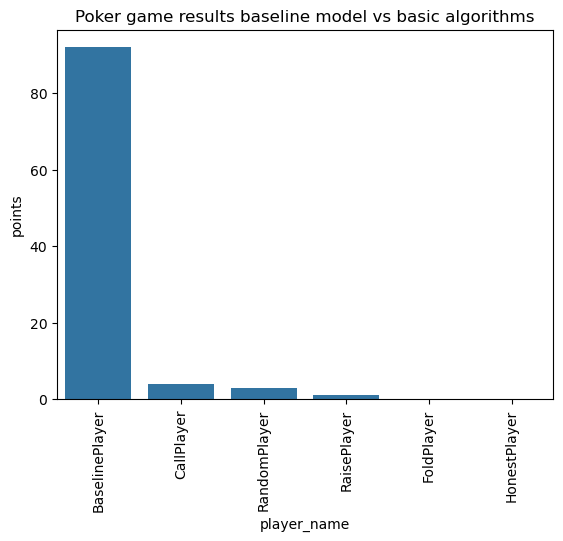

In [35]:
plot_poker_games_results(df_tournament_result, "baseline model vs basic algorithms")

We can see that for the 100 tournaments, the player using the Baseline model has won 92 times against the players with the basic algorithms.
The win rate for the Baseline model is 92%

# Game for classifier models semifinal 1
We will test our classifier models and make them play against each others.
For this we will use from our previous work in the notebook "04_Poker_model_improvement.ipynb", the best PKL models that we saved in the "models" folder for each of the different classifiers with the best performance metrics. 
We will split the classifier models into 2 groups first. To play the first semi final, the following classifier will compete against each others (they will all use the same baseline regression model for the prediction of the amount to raise) :
- Stacking Classifier
- Voting Classifier
- Decision Tree Classifier
- Support Vector Classifier
- AdaBoost Classifier
- Pasting Classifier
- Gaussian Naive Bayes

They will also play against our baseline classification model

In [36]:
df_player = pd.DataFrame(
    {'player_id': ['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8'], 
     'player_name': ['StackingClassifierPlayer', 'VotingClassifierPlayer', 'DecisionTreePlayer', 'SVCPlayer', 'AdaBoostClassifierPlayer', 'PastingClassifierPlayer', 'Gaussian_Naive_BayesPlayer', 'BaselinePlayer'], 
     'algorithm': [StackingClassifierPlayer(), VotingClassifierPlayer(), DecisionTreePlayer(), SVCPlayer(), AdaBoostClassifierPlayer(), PastingClassifierPlayer(), Gaussian_Naive_BayesPlayer(), BaselinePlayer()], 
    })
df_player.head(10)

,player_id,player_name,algorithm
0,p1,StackingClassifierPlayer,<__main__.StackingClassifierPlayer object at 0...
1,p2,VotingClassifierPlayer,<__main__.VotingClassifierPlayer object at 0x0...
2,p3,DecisionTreePlayer,<__main__.DecisionTreePlayer object at 0x00000...
3,p4,SVCPlayer,<__main__.SVCPlayer object at 0x000001E9F26FFC50>
4,p5,AdaBoostClassifierPlayer,<__main__.AdaBoostClassifierPlayer object at 0...
5,p6,PastingClassifierPlayer,<__main__.PastingClassifierPlayer object at 0x...
6,p7,Gaussian_Naive_BayesPlayer,<__main__.Gaussian_Naive_BayesPlayer object at...
7,p8,BaselinePlayer,<__main__.BaselinePlayer object at 0x000001E98...


In [37]:
df_tournament_result = play_poker_games(df_player)
df_tournament_result.head(10)

,player_name,points
0,StackingClassifierPlayer,34
1,VotingClassifierPlayer,31
3,SVCPlayer,18
2,DecisionTreePlayer,10
4,AdaBoostClassifierPlayer,7
5,PastingClassifierPlayer,0
6,Gaussian_Naive_BayesPlayer,0
7,BaselinePlayer,0


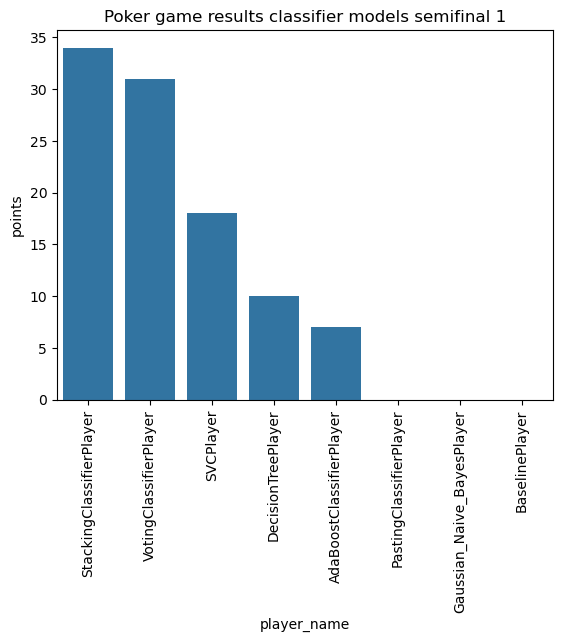

In [38]:
plot_poker_games_results(df_tournament_result, "classifier models semifinal 1")

We can see that for the 100 tournaments, for this first classifier semifinal, the best 2 classifiers were the Stacking Classifier and the Voting Classifier. We will keep only this top 2 to play the classifier final.
Note that the baseline classifier model finished last with 0 victory. The Gaussian Naive Bayes and the Pasting Classifiers were also last with 0 victory

# Game for classifier models semifinal 2
We will test our classifier models and make them play against each others.
For this we will use from our previous work in the notebook "04_Poker_model_improvement.ipynb", the best PKL models that we saved in the "models" folder for each of the different classifiers with the best performance metrics. 
We will split the classifier models into 2 groups first. To play the second semi final, the following classifier will compete against each others (they will all use the same baseline regression model for the prediction of the amount to raise) :
- XGBoost Classifier
- Random Forest Classifier
- K-Nearest Neighbors Classifier
- Gradient Boosting Classifier
- Bagging Classifier
- Logistic Regression Classifier

They will also play against our baseline classification model

In [39]:
df_player = pd.DataFrame(
    {'player_id': ['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7'], 
     'player_name': ['XGBClassifierPlayer', 'RandomForestClassifierPlayer', 'KNNPlayer', 'GradientBoostingClassifierPlayer', 'BaggingClassifierPlayer', 'Logistic_RegressionPlayer', 'BaselinePlayer'], 
     'algorithm': [XGBClassifierPlayer(), RandomForestClassifierPlayer(), KNNPlayer(), GradientBoostingClassifierPlayer(), BaggingClassifierPlayer(), Logistic_RegressionPlayer(), BaselinePlayer()], 
    })
df_player.head(10)

,player_id,player_name,algorithm
0,p1,XGBClassifierPlayer,<__main__.XGBClassifierPlayer object at 0x0000...
1,p2,RandomForestClassifierPlayer,<__main__.RandomForestClassifierPlayer object ...
2,p3,KNNPlayer,<__main__.KNNPlayer object at 0x000001E9BCB83170>
3,p4,GradientBoostingClassifierPlayer,<__main__.GradientBoostingClassifierPlayer obj...
4,p5,BaggingClassifierPlayer,<__main__.BaggingClassifierPlayer object at 0x...
5,p6,Logistic_RegressionPlayer,<__main__.Logistic_RegressionPlayer object at ...
6,p7,BaselinePlayer,<__main__.BaselinePlayer object at 0x000001E9B...


In [40]:
df_tournament_result = play_poker_games(df_player)
df_tournament_result.head(10)

,player_name,points
2,KNNPlayer,62
1,RandomForestClassifierPlayer,23
0,XGBClassifierPlayer,9
3,GradientBoostingClassifierPlayer,6
4,BaggingClassifierPlayer,0
5,Logistic_RegressionPlayer,0
6,BaselinePlayer,0


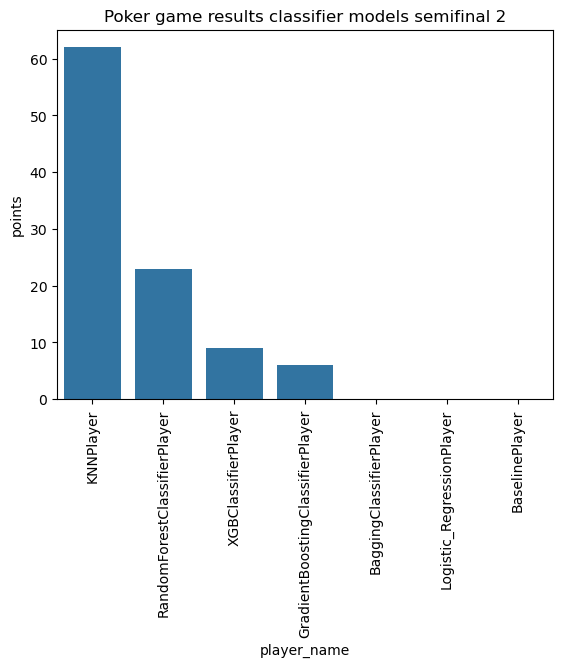

In [41]:
plot_poker_games_results(df_tournament_result, "classifier models semifinal 2")

We can see that for the 100 tournaments, for this second classifier semifinal, the best 2 classifiers were the K-Nearest Neighbors Classifier and the Random Forest Classifier. We will keep only this top 2 to play the classifier final.
Note that the baseline classifier model finished last with 0 victory. The Logistic Regression and Bagging Classifiers were also last with 0 victory

# Game for classifier models final
Now we play the final of the classifier models which involves the 2 winner of each semifinal.
Therefore, to play the final, the following classifiers will compete against each others (they will all use the same baseline regression model for the prediction of the amount to raise) :
- Stacking Classifier
- Voting Classifier
- K-Nearest Neighbors Classifier
- Random Forest Classifier

In [42]:
df_player = pd.DataFrame(
    {'player_id': ['p1', 'p2', 'p3', 'p4'], 
     'player_name': ['StackingClassifierPlayer', 'VotingClassifierPlayer', 'KNNPlayer', 'RandomForestClassifierPlayer'], 
     'algorithm': [StackingClassifierPlayer(), VotingClassifierPlayer(), KNNPlayer(), RandomForestClassifierPlayer()], 
    })
df_player.head(10)

,player_id,player_name,algorithm
0,p1,StackingClassifierPlayer,<__main__.StackingClassifierPlayer object at 0...
1,p2,VotingClassifierPlayer,<__main__.VotingClassifierPlayer object at 0x0...
2,p3,KNNPlayer,<__main__.KNNPlayer object at 0x000001E68F659BB0>
3,p4,RandomForestClassifierPlayer,<__main__.RandomForestClassifierPlayer object ...


In [43]:
df_tournament_result = play_poker_games(df_player)
df_tournament_result.head(10)

,player_name,points
2,KNNPlayer,35
1,VotingClassifierPlayer,31
3,RandomForestClassifierPlayer,21
0,StackingClassifierPlayer,13


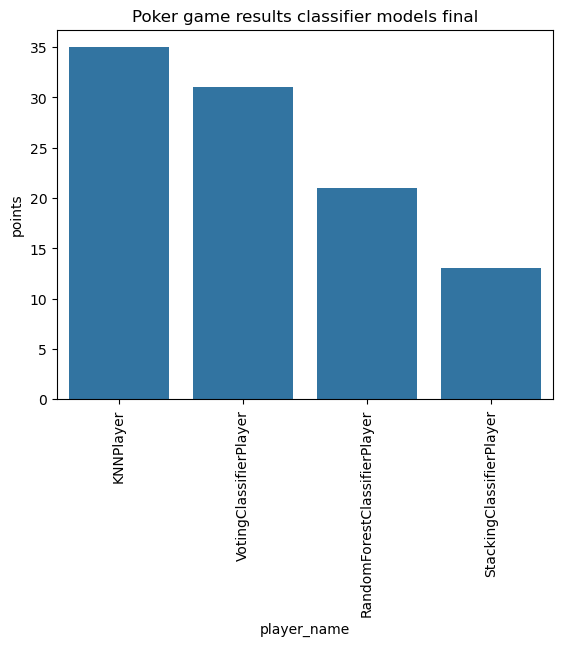

In [44]:
plot_poker_games_results(df_tournament_result, "classifier models final")

We can see that for the 100 tournaments, for the classifier final, the best classifiers are in this order: 1) K-Nearest Neighbors Classifier, 2) Voting Classifier, 3) Random Forest Classifier, 4) Stacking Classifier

# Game for regressor models semifinal 1
We will test our regressor models and make them play against each others.
For this we will use from our previous work in the notebook "04_Poker_model_improvement.ipynb", the best PKL models that we saved in the "models" folder for each of the different regressors with the best performance metrics. 
We will split the regressor models into 2 groups first. To play the first semi final, the following regressors will compete against each others (they will all use the same baseline classification model for the prediction of the action) :
- Stacking Regressor
- K-Nearest Neighbors Regressor
- Lasso Regression
- Linear Regression
- Support Vector Regressor

They will also play against our baseline regression model

In [56]:
df_player = pd.DataFrame(
    {'player_id': ['p1', 'p2', 'p3', 'p4', 'p5', 'p6'], 
     'player_name': ['StackingRegressorPlayer', 'KNNRegressorPlayer', 'LassoPlayer', 'LinearRegressionPlayer', 'SVRegressorPlayer', 'BaselinePlayer'], 
     'algorithm': [StackingRegressorPlayer(), KNNRegressorPlayer(), LassoPlayer(), LinearRegressionPlayer(), SVRegressorPlayer(), BaselinePlayer()], 
    })
df_player.head(10)

,player_id,player_name,algorithm
0,p1,StackingRegressorPlayer,<__main__.StackingRegressorPlayer object at 0x...
1,p2,KNNRegressorPlayer,<__main__.KNNRegressorPlayer object at 0x00000...
2,p3,LassoPlayer,<__main__.LassoPlayer object at 0x0000026E430C...
3,p4,LinearRegressionPlayer,<__main__.LinearRegressionPlayer object at 0x0...
4,p5,SVRegressorPlayer,<__main__.SVRegressorPlayer object at 0x000002...
5,p6,BaselinePlayer,<__main__.BaselinePlayer object at 0x0000026E4...


In [57]:
df_tournament_result = play_poker_games(df_player)
df_tournament_result.head(10)

,player_name,points
0,StackingRegressorPlayer,23
3,LinearRegressionPlayer,21
1,KNNRegressorPlayer,17
2,LassoPlayer,17
5,BaselinePlayer,12
4,SVRegressorPlayer,10


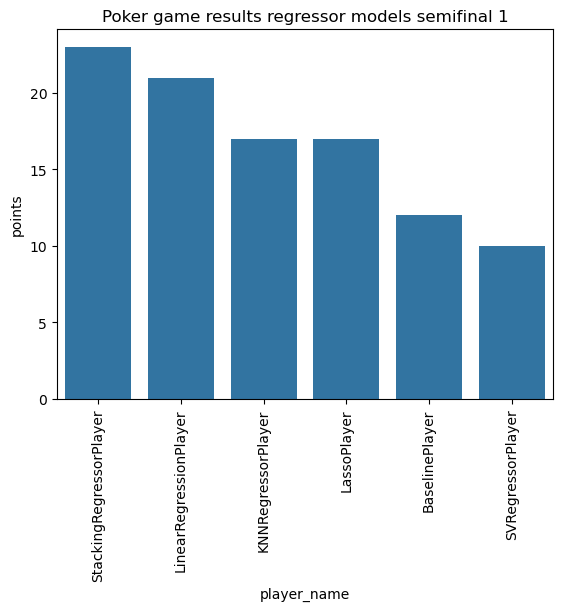

In [58]:
plot_poker_games_results(df_tournament_result, "regressor models semifinal 1")

We can see that for the 100 tournaments, for this first regressor semifinal, the best 2 regressor models were the Stacking Regressor and the Linear Regression. We will keep only this top 2 to play the regressor final.
Note that the baseline regressor model finished 5th and beated the Support Vector Regressor which finished last

# Game for regressor models semifinal 2
We will test our regressor models and make them play against each others.
For this we will use from our previous work in the notebook "04_Poker_model_improvement.ipynb", the best PKL models that we saved in the "models" folder for each of the different regressors with the best performance metrics. 
We will split the regressor models into 2 groups first. To play the second semi final, the following regressors will compete against each others (they will all use the same baseline classification model for the prediction of the action) :
- Voting Regressor
- Decision Tree Regressor
- Ridge Regression
- Stochastic Gradient Descent Regressor

They will also play against our baseline regression model

In [45]:
df_player = pd.DataFrame(
    {'player_id': ['p1', 'p2', 'p3', 'p4', 'p5'], 
     'player_name': ['VotingRegressorPlayer', 'DecisionTreeRegressorPlayer', 'RidgePlayer', 'SGDRegressorPlayer', 'BaselinePlayer'], 
     'algorithm': [VotingRegressorPlayer(), DecisionTreeRegressorPlayer(), RidgePlayer(), SGDRegressorPlayer(), BaselinePlayer()], 
    })
df_player.head(10)

,player_id,player_name,algorithm
0,p1,VotingRegressorPlayer,<__main__.VotingRegressorPlayer object at 0x00...
1,p2,DecisionTreeRegressorPlayer,<__main__.DecisionTreeRegressorPlayer object a...
2,p3,RidgePlayer,<__main__.RidgePlayer object at 0x000001E6AAF9...
3,p4,SGDRegressorPlayer,<__main__.SGDRegressorPlayer object at 0x00000...
4,p5,BaselinePlayer,<__main__.BaselinePlayer object at 0x000001E69...


In [46]:
df_tournament_result = play_poker_games(df_player)
df_tournament_result.head(10)

,player_name,points
0,VotingRegressorPlayer,25
1,DecisionTreeRegressorPlayer,25
3,SGDRegressorPlayer,24
2,RidgePlayer,21
4,BaselinePlayer,5


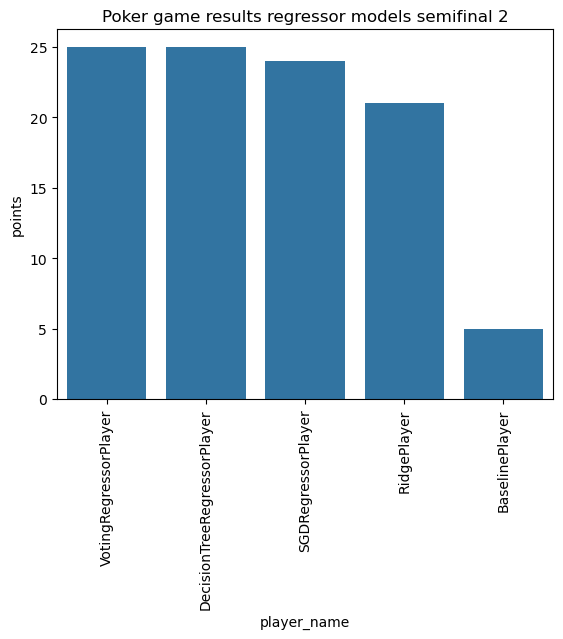

In [47]:
plot_poker_games_results(df_tournament_result, "regressor models semifinal 2")

We can see that for the 100 tournaments, for this second regressor semifinal, the best 2 regressor models were the Voting Regressor and the Decision Tree Regressor. We will keep only this top 2 to play the regressor final.
Note that the baseline regressor model finished last

# Game for regressor models final
Now we play the final of the regressor models which involves the 2 winner of each semifinal.
Therefore, to play the final, the following regressors will compete against each others (they will all use the same baseline classification model for the prediction of the action) :
- Stacking Regressor
- Linear Regression
- Voting Regressor
- Decision Tree Regressor

In [48]:
df_player = pd.DataFrame(
    {'player_id': ['p1', 'p2', 'p3', 'p4'], 
     'player_name': ['StackingRegressorPlayer', 'LinearRegressionPlayer', 'VotingRegressorPlayer', 'DecisionTreeRegressorPlayer'], 
     'algorithm': [StackingRegressorPlayer(), LinearRegressionPlayer(), VotingRegressorPlayer(), DecisionTreeRegressorPlayer()], 
    })
df_player.head(10)

,player_id,player_name,algorithm
0,p1,StackingRegressorPlayer,<__main__.StackingRegressorPlayer object at 0x...
1,p2,LinearRegressionPlayer,<__main__.LinearRegressionPlayer object at 0x0...
2,p3,VotingRegressorPlayer,<__main__.VotingRegressorPlayer object at 0x00...
3,p4,DecisionTreeRegressorPlayer,<__main__.DecisionTreeRegressorPlayer object a...


In [49]:
df_tournament_result = play_poker_games(df_player)
df_tournament_result.head(10)

,player_name,points
3,DecisionTreeRegressorPlayer,31
0,StackingRegressorPlayer,29
1,LinearRegressionPlayer,22
2,VotingRegressorPlayer,18


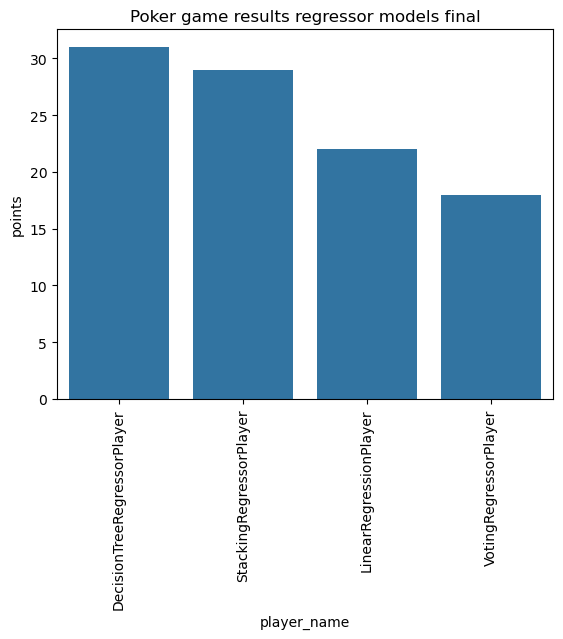

In [50]:
plot_poker_games_results(df_tournament_result, "regressor models final")

We can see that for the 100 tournaments, for the regressor final, the best regressors are in this order: 1) Decision Tree Regressor, 2) Stacking Regressor, 3) Linear Regression, 4) Voting Regressor

# Conclusion
- We are able to make our models from the previous notebook play against each other’s using a poker game engine. We created some tournaments to figure out which models beat the others in reel poker games. To play the poker games, we used the python library "pypokerengine"
- The player using the Baseline model has won 92% of the tournaments against some players using basic algorithms.
- The best classifiers are in this order: 1) K-Nearest Neighbors Classifier, 2) Voting Classifier, 3) Random Forest Classifier, 4) Stacking Classifier
- The best regressors are in this order: 1) Decision Tree Regressor, 2) Stacking Regressor, 3) Linear Regression, 4) Voting Regressor
- For those top 4 classifiers, we can see that in the previous notebook they were all in the top 6 classifiers by order of "Test F1 (weighted avg)". So the results from the game testing seem to be aligned with results of the ranking by the best performance metrics from the last notebook. However, we note that one of the top 2 classifiers from the previous notebook got disappointing results in the game testing: the XGBoost Classifier, as it didn't make it in the top 4 for the game testing
- For those top 4 regressors, we can see that in the previous notebook they were all in the top 4 regressors by order of "Test R2 Score", except for the Linear regression which is 3rd in the game testing but only 7th in the previous notebook by order of "Test R2 Score". Globaly, the results from the game testing seem to be aligned with results of the ranking by the best performance metrics from the last notebook
